In [192]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [193]:
df=pd.read_excel("../data/processed/Características y composición del hogar.xlsx")

Borramos los exactos duplicados.

In [194]:
df.drop_duplicates()

,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P6016,P1894,P6020,P6034,P6040,...,P1898,P1899,P3175,P1901,P1903,P1904,P1905,P1927,P3038,P3039
0,8369550,1,1,1,472.131901,1,3,2,1,45,...,10.0,5.0,7.0,10.0,6.0,0.0,7.0,6.0,1.0,2.0
1,8369550,2,1,2,472.131901,2,3,1,1,25,...,10.0,8.0,7.0,10.0,0.0,0.0,8.0,8.0,2.0,1.0
2,8369550,3,1,3,472.131901,3,2,2,1,16,...,10.0,10.0,10.0,10.0,0.0,0.0,10.0,10.0,NaN,NaN
3,8369550,4,1,4,472.131901,4,2,1,1,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8369551,1,1,1,308.854319,1,3,2,1,62,...,7.0,4.0,7.0,8.0,6.0,2.0,8.0,7.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235345,8489520,2,1,2,19.043528,2,3,2,1,31,...,10.0,10.0,10.0,10.0,1.0,0.0,9.0,9.0,1.0,2.0
235346,8489520,3,1,3,19.043528,3,1,2,1,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235347,8489521,1,1,1,19.043528,1,3,1,1,31,...,10.0,9.0,9.0,10.0,1.0,0.0,10.0,9.0,2.0,1.0
235348,8489521,2,1,2,19.043528,2,3,2,1,32,...,10.0,10.0,9.0,9.0,1.0,1.0,10.0,9.0,1.0,2.0


Para las variables seleccionadas, evalúen la calidad de los datos. Identifiquen cuántos valores faltantes o nulos presenta cada variable y qué proporción representan respecto al total de registros.

hacemos un nuevo df unicamente con las variable que usamos.

In [195]:
df_variables=df[["P6040","P756","P756S1","P756S2","P756S3","P1895","P1896","P1897","P1898","P1899","P3175"]]
df_variables

,P6040,P756,P756S1,P756S2,P756S3,P1895,P1896,P1897,P1898,P1899,P3175
0,45,1,NaN,NaN,NaN,8.0,99.0,10.0,10.0,5.0,7.0
1,25,1,NaN,NaN,NaN,10.0,8.0,10.0,10.0,8.0,7.0
2,16,1,NaN,NaN,NaN,10.0,99.0,10.0,10.0,10.0,10.0
3,10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,62,2,13.0,13433.0,NaN,5.0,4.0,7.0,7.0,4.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...
235345,31,1,NaN,NaN,NaN,10.0,10.0,10.0,10.0,10.0,10.0
235346,8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235347,31,1,NaN,NaN,NaN,10.0,10.0,10.0,10.0,9.0,9.0
235348,32,1,NaN,NaN,NaN,10.0,10.0,9.0,10.0,10.0,9.0


Filtramos con la variable que nos dice la edad de cada encuestado para solo tener en cuenta aquellos mayores a 18.

In [196]:
df_variables_filtrado=df_variables.query("P6040>=18")

Conocemos los porcentajes de valores nulos para cada variable.

In [197]:
(df_variables_filtrado.isna().mean()*100).sort_values(ascending=False)

P756S3    96.923122
P756S2    63.720389
P756S1    63.720389
P756       0.000000
P6040      0.000000
P1895      0.000000
P1896      0.000000
P1897      0.000000
P1898      0.000000
P1899      0.000000
P3175      0.000000
dtype: float64

Cambiamos NaN que puedan ser reemplazados por No aplica

In [198]:
df_variables_filtrado.dtypes

P6040       int64
P756        int64
P756S1    float64
P756S2    float64
P756S3    float64
P1895     float64
P1896     float64
P1897     float64
P1898     float64
P1899     float64
P3175     float64
dtype: object

## Analisis descriptivo 

In [199]:
df_variables_filtrado.columns 

Index(['P6040', 'P756', 'P756S1', 'P756S2', 'P756S3', 'P1895', 'P1896',
       'P1897', 'P1898', 'P1899', 'P3175'],
      dtype='str')

La variable  **P6040 - ¿Cuántos años cumplidos tiene?** es una variable de tipo numérico discreto que cuenta con una media de 45.84, una mediana de 44, un valor maximo de 108 y un valor minimo de 18. 

In [200]:
df_variables_filtrado["P6040"].describe()

count    172025.000000
mean         45.844046
std          17.972662
min          18.000000
25%          31.000000
50%          44.000000
75%          60.000000
max         108.000000
Name: P6040, dtype: float64

In [201]:
df_variables_filtrado["P6040"].median()

np.float64(44.0)

La variable **P1895 - En general, ¿qué tan satisfecho/a se siente con su vida actualmente?** es una variable de tipo numérico discreto que cuenta con una media de 7, una mediana de 7, un valor maximo de 10 y un valor minimo de 0. 


In [202]:
df_variables_filtrado["P1895"].describe()

count    172025.000000
mean          8.142224
std           1.634644
min           0.000000
25%           7.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: P1895, dtype: float64

In [203]:
df_variables_filtrado["P1895"].median()

np.float64(8.0)

La variable **P1896 - En general, ¿qué tan satisfecho/a se siente con su ingreso actualmente?** es una variable de tipo numérico discreto que cuenta con una media de 7, una mediana de 7, un valor maximo de 10 y un valor minimo de 0. 


In [204]:
df_variables_filtrado["P1896"].unique()
df_variables_filtrado["P1896"].value_counts()

P1896
8.0     30799
7.0     25626
99.0    21681
6.0     19081
10.0    17703
5.0     17386
9.0     14440
4.0      8694
3.0      7044
2.0      4521
0.0      2687
1.0      2363
Name: count, dtype: int64

In [205]:
df_variables_filtrado["P1896"] = df_variables_filtrado["P1896"].replace(99.0, 7.0)

In [206]:
df_variables_filtrado["P1896"].unique()

array([ 7.,  8.,  4.,  9.,  1.,  0.,  5.,  3., 10.,  6.,  2.])

In [207]:
df_variables_filtrado["P1896"].describe()

count    172025.000000
mean          6.704026
std           2.212583
min           0.000000
25%           6.000000
50%           7.000000
75%           8.000000
max          10.000000
Name: P1896, dtype: float64

In [208]:
df_variables_filtrado["P1896"].median()

np.float64(7.0)

La variable **P1897 - En general, ¿qué tan satisfecho/a se siente con su salud actualmente?** es una variable de tipo numérico discreto que cuenta con una media de 7.83, una mediana de 8, un valor maximo de 10 y un valor minimo de 0. 

In [209]:
df_variables_filtrado["P1897"].describe()

count    172025.000000
mean          7.839128
std           1.873769
min           0.000000
25%           7.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: P1897, dtype: float64

In [210]:
df_variables_filtrado["P1897"].median()

np.float64(8.0)

La variable **P1898 - En general, ¿qué tan satisfecho/a se siente con su nivel de seguridad actualmente?** es una variable de tipo numérico discreto que cuenta con una media de 7.75, una mediana de 8, un valor maximo de 10 y un valor minimo de 0. 

In [211]:
df_variables_filtrado["P1898"].describe()

count    172025.000000
mean          7.759564
std           1.948263
min           0.000000
25%           7.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: P1898, dtype: float64

In [212]:
df_variables_filtrado["P1898"].median()

np.float64(8.0)

La variable **P1899 - En general, ¿qué tan satisfecho/a se siente con su trabajo/actividad actualmente?** es una variable de tipo numérico discreto que cuenta con una media de 7.35, una mediana de 8, un valor maximo de 10 y un valor minimo de 0. 

In [213]:
df_variables_filtrado["P1899"].describe()

count    172025.000000
mean          7.354739
std           2.201839
min           0.000000
25%           6.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: P1899, dtype: float64

In [214]:
df_variables_filtrado["P1899"].median()

np.float64(8.0)

La variable **P3175 - En general, ¿qué tan satisfecho/a se siente con su tiempo libre?** es una variable de tipo numérico discreto que cuenta con una media de 7.58, una mediana de 8, un valor maximo de 10 y un valor minimo de 0. 

In [215]:
df_variables_filtrado["P3175"].describe()

count    172025.000000
mean          7.585781
std           1.909613
min           0.000000
25%           7.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: P3175, dtype: float64

In [216]:
df_variables_filtrado["P3175"].median()

np.float64(8.0)

### Correlacion 

In [217]:
df_variables_filtrado[["P6040", "P1895"]].corr()

,P6040,P1895
P6040,1.00000,-0.06375
P1895,-0.06375,1.00000


In [218]:
df_variables_filtrado[["P6040", "P1895"]].corr(method="spearman")

,P6040,P1895
P6040,1.000000,-0.050822
P1895,-0.050822,1.000000


### Valores atipicos

In [219]:
z=(df_variables_filtrado["P6040"]-df_variables_filtrado["P6040"].mean())/df_variables_filtrado["P6040"].std()
z


0        -0.046963
1        -1.159764
4         0.898918
5        -0.436443
6         0.175597
            ...   
235344   -0.770284
235345   -0.825924
235347   -0.825924
235348   -0.770284
235349   -0.046963
Name: P6040, Length: 172025, dtype: float64

In [220]:
df_variables_filtrado.assign(valores_atipicos_edad= z).query("valores_atipicos_edad >= 3")

,P6040,P756,P756S1,P756S2,P756S3,P1895,P1896,P1897,P1898,P1899,P3175,valores_atipicos_edad
474,103,2,25.0,25862.0,NaN,10.0,7.0,5.0,10.0,5.0,5.0,3.180161
38673,103,2,76.0,76246.0,NaN,7.0,7.0,7.0,7.0,8.0,7.0,3.180161
47234,100,1,NaN,NaN,NaN,2.0,7.0,5.0,3.0,0.0,6.0,3.013241
49453,105,1,NaN,NaN,NaN,3.0,6.0,4.0,8.0,3.0,7.0,3.291441
61584,104,2,73.0,73001.0,NaN,9.0,7.0,7.0,8.0,8.0,8.0,3.235801
80413,103,2,13.0,13001.0,NaN,4.0,6.0,4.0,4.0,4.0,4.0,3.180161
92082,100,2,66.0,66440.0,NaN,5.0,7.0,5.0,10.0,4.0,10.0,3.013241
92940,100,2,70.0,70670.0,NaN,8.0,8.0,9.0,8.0,8.0,8.0,3.013241
98955,101,1,NaN,NaN,NaN,5.0,5.0,5.0,5.0,5.0,5.0,3.068881
109033,100,1,NaN,NaN,NaN,7.0,7.0,8.0,8.0,8.0,6.0,3.013241


<Axes: >

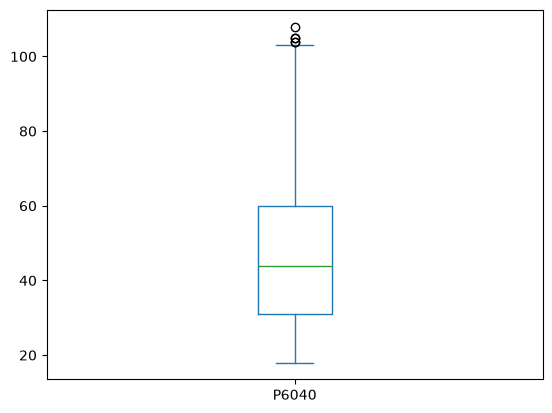

In [221]:
df_variables_filtrado["P6040"].plot.box()

In [222]:
df_variables_filtrado = df_variables_filtrado.query("P6040 < 100")
df_variables_filtrado

,P6040,P756,P756S1,P756S2,P756S3,P1895,P1896,P1897,P1898,P1899,P3175
0,45,1,NaN,NaN,NaN,8.0,7.0,10.0,10.0,5.0,7.0
1,25,1,NaN,NaN,NaN,10.0,8.0,10.0,10.0,8.0,7.0
4,62,2,13.0,13433.0,NaN,5.0,4.0,7.0,7.0,4.0,7.0
5,38,1,NaN,NaN,NaN,8.0,8.0,8.0,5.0,8.0,8.0
6,49,1,NaN,NaN,NaN,8.0,9.0,8.0,5.0,8.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...
235344,32,1,NaN,NaN,NaN,9.0,9.0,9.0,10.0,10.0,9.0
235345,31,1,NaN,NaN,NaN,10.0,10.0,10.0,10.0,10.0,10.0
235347,31,1,NaN,NaN,NaN,10.0,10.0,10.0,10.0,9.0,9.0
235348,32,1,NaN,NaN,NaN,10.0,10.0,9.0,10.0,10.0,9.0
